# Exploring Image Preprocessing and  Affine Normalizations



In [1]:
!pip install --upgrade pip
!pip install numpy
##!pip install numpy==1.26.4
!pip install --upgrade bottleneck
!pip install torch torchvision torchaudio

In [1]:
import numpy as np
import bottleneck
print(np.__version__)
print(bottleneck.__version__)

2.3.4
1.6.0


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
#import numpy as np
import seaborn as sns
#import bottleneck

import os
import urllib.request
import tarfile

from PIL import Image
from collections import Counter

import random

import torch
from torchvision import  datasets, transforms
from torch.utils.data import Dataset

## Moving inside the directory

Starting from the current working directory *notebooks*, there are two common ways to navigate to the project root directory (in my case it is "Flowers") using the  *os.path* submodule of the *os* module:

1. Direct way, using os.path.dirname().

This function returns the directory name of the path provided. If you pass the path of the notebooks folder to it, it will return the parent directory, which is "Flowers".

In [3]:
current_dir = os.getcwd()  # get current working directory
current_dir

'C:\\Users\\normaqp\\Dropbox\\PyTorch\\Image_Preprocessing_Affine_Normalizations'

In [4]:
#=====================
# case 1 : direct way
#=====================

root_dir = os.path.dirname(current_dir)
root_dir

'C:\\Users\\normaqp\\Dropbox\\PyTorch'

2.  Constructing paths by using os.path.join() + os.path.abspath()

This method involves building a relative path and then "flattening" it into a clean, absolute path.

Step A: os.path.join(current_dir, "..") creates a path string like Flowers/notebooks/...

Step B: os.path.abspath(...) resolves the .. (parent directory) symbol, removing the "notebooks" portion and returning the clean absolute path to Flowers.

In [5]:
#=============================
# case 2: constructing paths
#=============================

# Step A: os.path.join produce the following
my_path = os.path.join(current_dir, "..")
my_path


'C:\\Users\\normaqp\\Dropbox\\PyTorch\\Image_Preprocessing_Affine_Normalizations\\..'

In [6]:
# Step B:
my_root_dir = os.path.abspath(my_path)
my_root_dir

'C:\\Users\\normaqp\\Dropbox\\PyTorch'

## Loading the dataset

In [7]:
#======================================================
# Loading the full dataset
#======================================================

# Dataset URL
URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# -----------------------------------------------------
# Project-relative data directories (os.path version)
# -----------------------------------------------------

data_dir = "../data"
raw_dir = os.path.join(data_dir, "raw")
extracted_dir = os.path.join(data_dir, "extracted")


# Create directories if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(extracted_dir, exist_ok=True)

# Archive path
cps_archive_path = os.path.join(raw_dir, "flower_photos.tgz")

# -----------------------------------------------------
# Download the dataset
# -----------------------------------------------------
if not os.path.exists(cps_archive_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(URL, cps_archive_path)

# -----------------------------------------------------
# Extract the dataset
# -----------------------------------------------------
with tarfile.open(cps_archive_path) as tar:
    tar.extractall(path=extracted_dir, filter="data")

# Dataset root folder
flowers_dir = os.path.join(extracted_dir, "flower_photos")

print("Flowers dataset folder ready at:", flowers_dir)

# -----------------------------------------------------
# List class folders (ignore LICENSE.txt)
# -----------------------------------------------------
class_dirs = sorted([
    name for name in os.listdir(flowers_dir)
    if os.path.isdir(os.path.join(flowers_dir, name))
])

print("Subfolders:", class_dirs)


Flowers dataset folder ready at: ../data\extracted\flower_photos
Subfolders: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Selecting the class "dandelion"

In [8]:
dandelion_dir = os.path.join(flowers_dir, "dandelion")

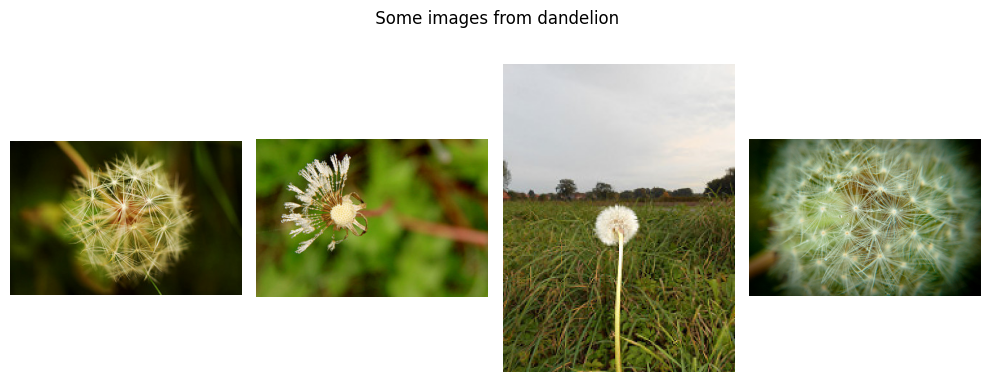

In [9]:
# see the first 4 dandelion flowers

files = [name for name in os.listdir(dandelion_dir)]

# Select first 3 images (or change number)
files_sample = files[: 4]

# Plot
plt.figure(figsize=(10, 4))

for i, filename in enumerate(files_sample):
    img_path = os.path.join(dandelion_dir, filename)
    img = Image.open(img_path)
   

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.axis("off")
plt.suptitle(f" Some images from dandelion")
plt.tight_layout()
plt.show()

## Exploring the dataset "dandelion"

In [10]:
#================================
# Inspecting Image Formats
#================================

format_counter = Counter()

for filename in os.listdir(dandelion_dir):
    img_path = os.path.join(dandelion_dir, filename)
    try:
        with Image.open(img_path) as img:
            format_counter[img.format] += 1
    except Exception as e:
        print("Problem with:", filename, e)

for fmt, count in format_counter.items():
    print(fmt, ":", count)


JPEG : 898


All images are in jpeg format. 

In [11]:
#======================================
# Checking the shapes of the images and counting them
#======================================

shape_counter = Counter()

for filename in os.listdir(dandelion_dir):
    img_path = os.path.join(dandelion_dir, filename)
    img = Image.open(img_path)
    shape_counter[np.array(img).shape] += 1

for shape, count in shape_counter.items():
    print(shape, "→", count)


(213, 320, 3) → 74
(218, 320, 3) → 3
(240, 180, 3) → 33
(339, 500, 3) → 2
(240, 320, 3) → 143
(375, 500, 3) → 24
(296, 500, 3) → 1
(335, 500, 3) → 5
(281, 500, 3) → 21
(315, 500, 3) → 3
(333, 500, 3) → 188
(240, 240, 3) → 80
(241, 320, 3) → 4
(240, 175, 3) → 1
(436, 500, 3) → 1
(240, 192, 3) → 2
(221, 240, 3) → 2
(226, 240, 3) → 1
(334, 500, 3) → 23
(283, 320, 3) → 1
(223, 320, 3) → 1
(337, 500, 3) → 1
(228, 320, 3) → 7
(336, 500, 3) → 1
(243, 320, 3) → 2
(236, 320, 3) → 2
(238, 320, 3) → 3
(331, 500, 3) → 10
(332, 500, 3) → 26
(217, 240, 3) → 1
(253, 320, 3) → 1
(309, 500, 3) → 2
(295, 500, 3) → 1
(266, 500, 3) → 1
(239, 240, 3) → 2
(282, 500, 3) → 3
(223, 240, 3) → 3
(313, 500, 3) → 3
(240, 235, 3) → 1
(240, 189, 3) → 2
(301, 500, 3) → 3
(240, 193, 3) → 1
(260, 500, 3) → 1
(212, 320, 3) → 10
(376, 500, 3) → 1
(227, 240, 3) → 1
(229, 320, 3) → 3
(329, 500, 3) → 2
(322, 500, 3) → 2
(225, 240, 3) → 2
(234, 320, 3) → 3
(240, 159, 3) → 22
(224, 240, 3) → 2
(400, 500, 3) → 1
(221, 320, 3) 

The images in the dataset exhibit varying resolutions. To ensure a uniform input shape for the model during training, all images have to be downsampled to a fixed standard resolution (resized to a fixed Height and Width).

In [12]:
#==============================================
# Showing the first 5 names of the dandelion files
#==============================================
files = os.listdir(dandelion_dir)
print(len(files))
print(files[:5])  

898
['10043234166_e6dd915111_n.jpg', '10200780773_c6051a7d71_n.jpg', '10294487385_92a0676c7d_m.jpg', '10437652486_aa86c14985.jpg', '10443973_aeb97513fc_m.jpg']


In [13]:
#==============================================
# Looking for grayscale images
#==============================================
if img.mode != "RGB":
    print(filename, img.mode)
else:
    print("The dataset contains no grayscale images; all samples are in RGB format.")

The dataset contains no grayscale images; all samples are in RGB format.


In [14]:
#==============================================
# Looking for corrupted images
#==============================================

try:
    img = Image.open(img_path)
    img.verify()
except Exception as e:
    print("Broken:", filename, e)


## Selecting one image to understand basic transformations

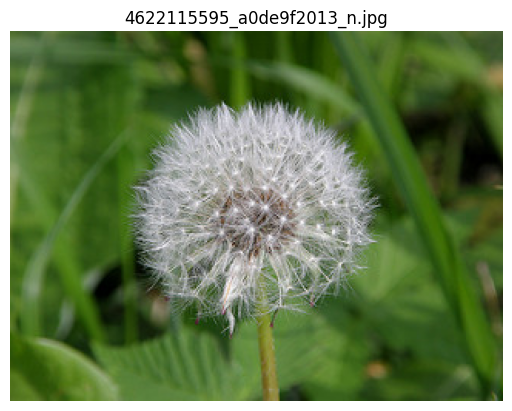

File: 4622115595_a0de9f2013_n.jpg
PIL size (Width, Height): (320, 240)
Pixel format: RGB
Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


In [15]:
#==================================================
# Select one image randomly and show its properties
#==================================================
random.seed(30) 
sample_file = random.choice(files)
sample_path = os.path.join(dandelion_dir, sample_file)


image_spl = Image.open(sample_path)   # PIL image

# plotting the image
plt.imshow(image_spl)
plt.title(sample_file)
plt.axis("off")
plt.show()

print("File:", sample_file)
print("PIL size (Width, Height):", image_spl.size)   # 2D geometry 
print("Pixel format:", image_spl.mode)
print("Type:", type(image_spl))



* The image dimensions are width  $W=320$ and height $H=240$.

* There are three color channels $(C=3)$, corresponding to the RGB space.

* The images are processed as PIL (Python Imaging Library) objects.

## Image Preprocessing for the selected image



Although there are several techniques for preprocessing images, here I´m focusing on three steps to prepare data for the analysis with PyTorch:

1. Resize
2. Tensor transformation
3. Affine transformation


###  1. Resize
In the  first case, the image dimensions defined by $W$ and $H$ are resized. Here I have only an image, but when training the full set of images, it is important to resize all images into an uniform  size. This is required for faster computation, less memory usage and it anables to use of batches which requires tensors of identical shape. 

Here, I choose $W = 240$ and $H = 240$.

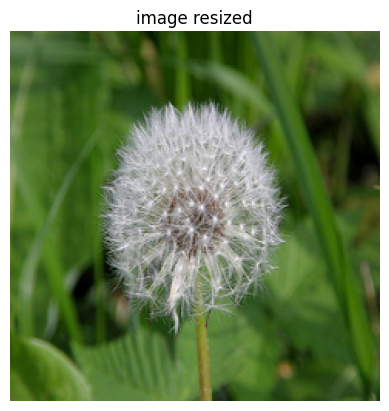

File: 4622115595_a0de9f2013_n.jpg
PIL size (Width, Height): (240, 240)


In [16]:
#========================
# resizing image
#=========================
image_resize= image_spl.resize((240, 240))    # resize H, W


# plotting the resized image
plt.imshow(image_resize)
plt.title("image resized")
plt.axis("off")
plt.show()

print("File:", sample_file)
print("PIL size (Width, Height):", image_resize.size)

### 2. Tensor Transformation

To process images with PyTorch, images must be converted into tensors with layout $(C, H, W)$, where: 

   C = number of channels,
   
   H = height,

   W = width.

  
   
   The transformation pipeline is the following:

a) Layout conversion: PIL.Image → np.array()

   Images are first converted from the format used by libraries such as PIL or OpenCV into a NumPy array using np.array(pil_image).
  

   


In [17]:
# a)  From pil image  to numpy array
image_np = np.array(image_resize)
print("NumPy shape:", np.array(image_np).shape)

NumPy shape: (240, 240, 3)


Note that  the PIL image has layout $(W, H)$ and that *np.array(pil_image)* interchanges $W$ and $H$,  and rearrange the pixel format into 3 channels. In this way, the shape of the numpy array  becomes $(H, W, C)$. 




b) Tensor conversion: NumPy array → torch.from_numpy()

   The NumPy array is then converted into a PyTorch tensor using torch.from_numpy().



In [18]:
# b) Transforming np array to tensor 
image_tensor = torch.from_numpy(image_np)

c) Layout permutation: tensor.permute(2, 0, 1)

   The resulting tensor initially has layout (H, W, C). However, PyTorch expects image tensors to follow the (C, H, W) convention.
   Therefore, a permutation of the tensor dimensions is required. 

  

In [19]:
# c) Permute layout
image = image_tensor.permute(2,0,1)
image.shape

torch.Size([3, 240, 240])

This operation rearranges the dimensions from $(H, W, C)$ to $(C, H, W)$.

### 3.  Affin transformation as pixel normalization



So far, the tensor obtained has integer pixel values.

In [20]:
# Looking  at the pixel  RGB values

print("For the pixel located at (H,W) = (150,100), the RGB values are:", image_np[150, 100])
print("For the pixel located at (H,W)= (239,18), the RGB values are :",  image_np[239, 18])


For the pixel located at (H,W) = (150,100), the RGB values are: [209 208 205]
For the pixel located at (H,W)= (239,18), the RGB values are : [52 90 13]


In [21]:
print(image_np.dtype)
print(image_np.min(), image_np.max())


uint8
0 254


The RGB pixel values are  8-bit-integers $unit8 \in [0,255]$.

Neural networks work well with floating-point numbers in intervals such as $[0,1]$,  $[-1,1]$ or something similar, since within these  small intervals the gradient tends to remain stable during training (otherwise, it may explode).

Therefore, the next preprocessing step is to scale the pixel values from the original interval $[0,255]$ to a small one.



#### 3.1 Scaling

To scale the original pixel interval from $[0,255]$ to  $[0,1]$, the pixel data is multiplied by the factor  $1/X_{\small{\mbox{max}⁡}}$, i.e.,

$$X \rightarrow \frac{X}{X_{\small{\mbox{max}⁡}}}\,,$$⁡ 

where $X_{\small{\mbox{max}⁡}}$ is the maximum pixel value in the original interval.  For pixel values $X∈[0,255]  \rightarrow [0,1]$ 

* Actually, this scaling is a particular case of the Min-Max normalization
$$
X^\prime = \frac{(X-X_{min})}{X_{max} - X_{min}}
$$
For the case $X_{min} = 0$, there is not translations and the transformation is only  $X^\prime = X/X_{max} \,.$ 







In [22]:
#================================================
# Scaling the pixel values between [0,1]
#================================================
image_scaled = image.float() / 255.
print(image_scaled)
print("---------------------------------------------------------------------------------------------------")
print("For the pixel located at (H,W) = (150,100), the RGB values are:", image_scaled[:,150, 100])
print("For the pixel located at (H,W)= (239,18), the RGB values are :",  image_scaled[:,239, 18])

tensor([[[0.3059, 0.3059, 0.2980,  ..., 0.2980, 0.2902, 0.2863],
         [0.3137, 0.3137, 0.3059,  ..., 0.2824, 0.2784, 0.2784],
         [0.3294, 0.3294, 0.3216,  ..., 0.2667, 0.2706, 0.2706],
         ...,
         [0.3059, 0.3176, 0.3176,  ..., 0.1961, 0.0941, 0.0667],
         [0.3176, 0.3294, 0.3294,  ..., 0.2235, 0.1059, 0.0902],
         [0.3255, 0.3373, 0.3373,  ..., 0.2275, 0.1333, 0.1294]],

        [[0.4235, 0.4235, 0.4157,  ..., 0.3804, 0.3725, 0.3686],
         [0.4314, 0.4314, 0.4235,  ..., 0.3647, 0.3608, 0.3608],
         [0.4471, 0.4471, 0.4392,  ..., 0.3490, 0.3529, 0.3529],
         ...,
         [0.4275, 0.4431, 0.4510,  ..., 0.2941, 0.2471, 0.2235],
         [0.4392, 0.4549, 0.4549,  ..., 0.3373, 0.2510, 0.2039],
         [0.4471, 0.4627, 0.4627,  ..., 0.3647, 0.2706, 0.1882]],

        [[0.1725, 0.1765, 0.1804,  ..., 0.2196, 0.2157, 0.2078],
         [0.1804, 0.1843, 0.1882,  ..., 0.2039, 0.2039, 0.2000],
         [0.2000, 0.2039, 0.2039,  ..., 0.1882, 0.1922, 0.

#### 3.2 (Z-score) normalization 

Another option to reduce the pixel value interval is to use Z-score normalization (or standardization). This consists of transforming the data $X$ into 

 $$
Z = \frac{X - \mu}{\sigma}
 $$

with $\mu$  the mean and $\sigma$ the standard deviation. The transformed data has a zero mean and a standard deviation equal to one. 

In image processing, this transformation is applied to each color channel. In such a case, the mean and standard deviation are computed separately for each channel, and each pixel is subsequently normalized using its channel's statistics. 

For the selected image, I want to see the effect of this transformation on the pixel values. Therefore, prior to the Z-normalization, I plotted the histograms below to visualize the pixel distribution of each channel.

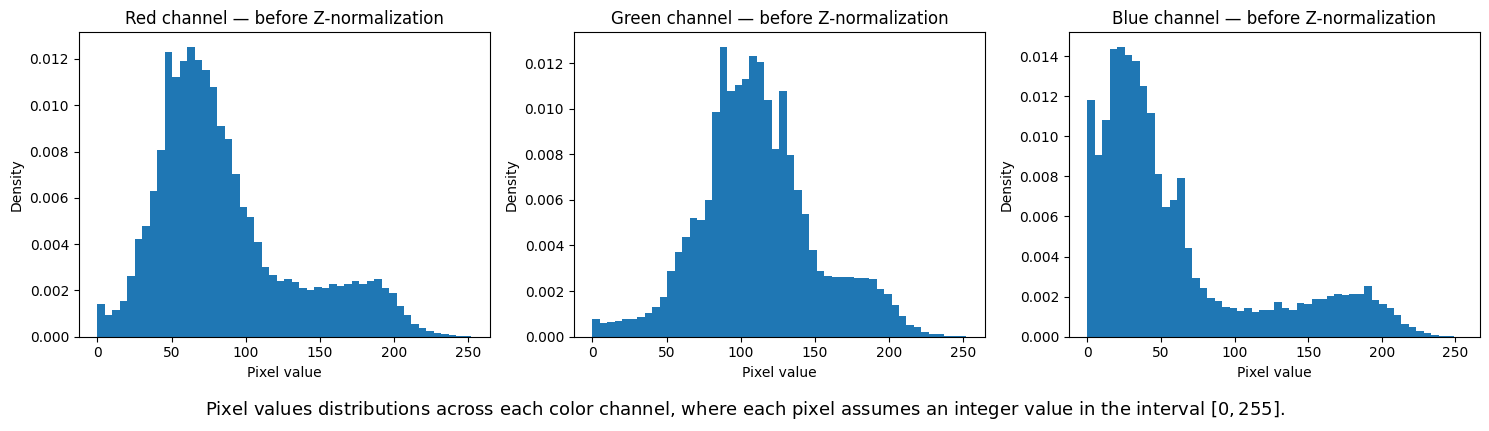

In [23]:
#================================================
# Looking at the pixel distribution before Z-normalization
#================================================
channel_names = ["Red", "Green", "Blue"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for c in range(3):
    axes[c].hist(image[c].flatten(), bins=50, density=True)
    axes[c].set_title(f"{channel_names[c]} channel — before Z-normalization")
    axes[c].set_xlabel("Pixel value")
    axes[c].set_ylabel("Density")
    

caption_text = 'Pixel values distributions across each color channel, where each pixel assumes an integer value in the interval $[0, 255]$.'
fig.text(0.5, -0.05, caption_text, ha='center', fontsize=13)
plt.tight_layout()
plt.show()


The distributions are right-skewed, and the range of pixel values is the same for each channel.

In [24]:
#================================================
# Z-normalization 
#================================================

# computes mean/std per channel automatically
means = image.float().mean(dim=(1,2), keepdim=True)
stds  = image.float().std(dim=(1,2), keepdim=True)

image_znorm = (image - means) / stds


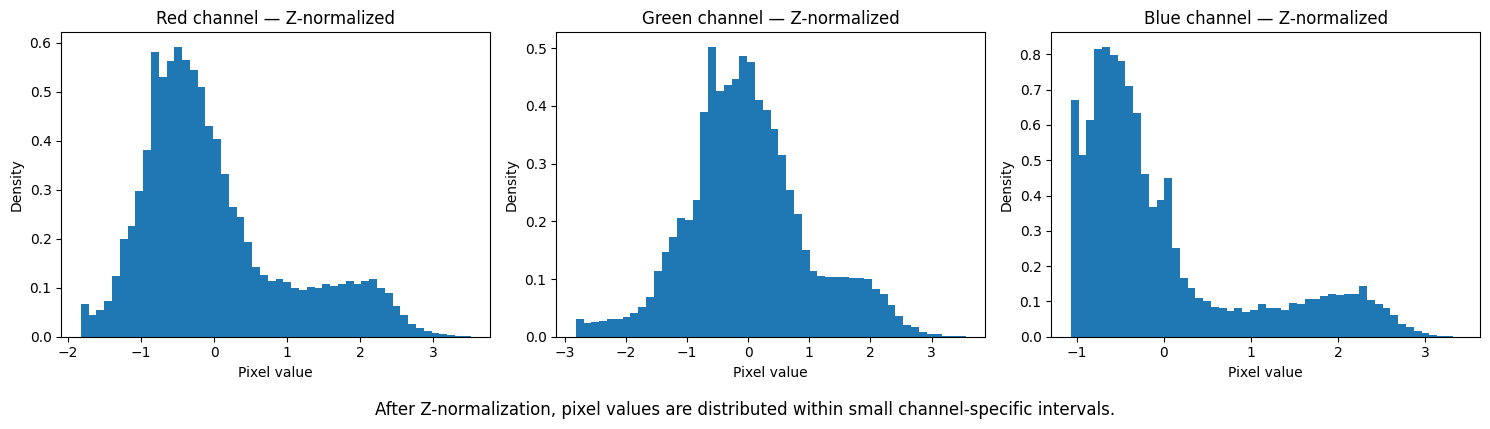

In [25]:
# Looking for the pixel distribution after Z-normalization
channel_names = ["Red", "Green", "Blue"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for c in range(3):
    axes[c].hist(image_znorm[c].flatten(), bins=50, density=True)
    axes[c].set_title(f"{channel_names[c]} channel — Z-normalized")
    axes[c].set_xlabel("Pixel value")
    axes[c].set_ylabel("Density")
    
caption_text = 'After Z-normalization, pixel values are distributed within small channel-specific intervals.'
fig.text(0.5, -0.05, caption_text, ha='center', fontsize=12)

plt.tight_layout()
plt.show()


After the Z-normalization:
* The distributions are centered around the mean 0 with a standard deviation of 1. 
* Skewness is preserved.  
* The resulting pixel value ranges are smaller and differ across the channels




In [26]:
# Pixel value intervals across channels
channel_names = ["Red", "Green", "Blue"]

for c in range(len(channel_names)):
    # Use unique variable names that aren't Python keywords
    val_max = image_znorm[c].max()
    val_min = image_znorm[c].min()
    
    # Use .item() to get a clean Python number if you're just printing
    print(f"Channel {channel_names[c]} | Min: {val_min.item():.2f} | Max: {val_max.item():.2f}")

Channel Red | Min: -1.82 | Max: 3.51
Channel Green | Min: -2.82 | Max: 3.55
Channel Blue | Min: -1.07 | Max: 3.40





#### 3.3 Normalization with a constant value

If the inputs to a neuron are all positive, the gradients of the weights in that neuron tend to have the same sign. This forces gradient descent to move in a zig-zag path instead of going directly toward the minimum. This causes slower convergence and inefficient learning. To mitigate this, the following transformation is applied to ensure the data includes both positive and negative values:

$$
X^\prime = \frac{X- c}{c}
$$

If the dataset takes positive values starting at 0, we can set  $c = max⁡(X)/2$ so that the data are first centered at 0 and then scaled to the interval [−1, 1].

For instance,  for the  original pixel values $X∈[0, 255]$, we choose the constant $c = 255/2$, this means the minimum value $0$ is transformed to $-1$, and the maximum value $255$ becomes $1$ after  this normalization.













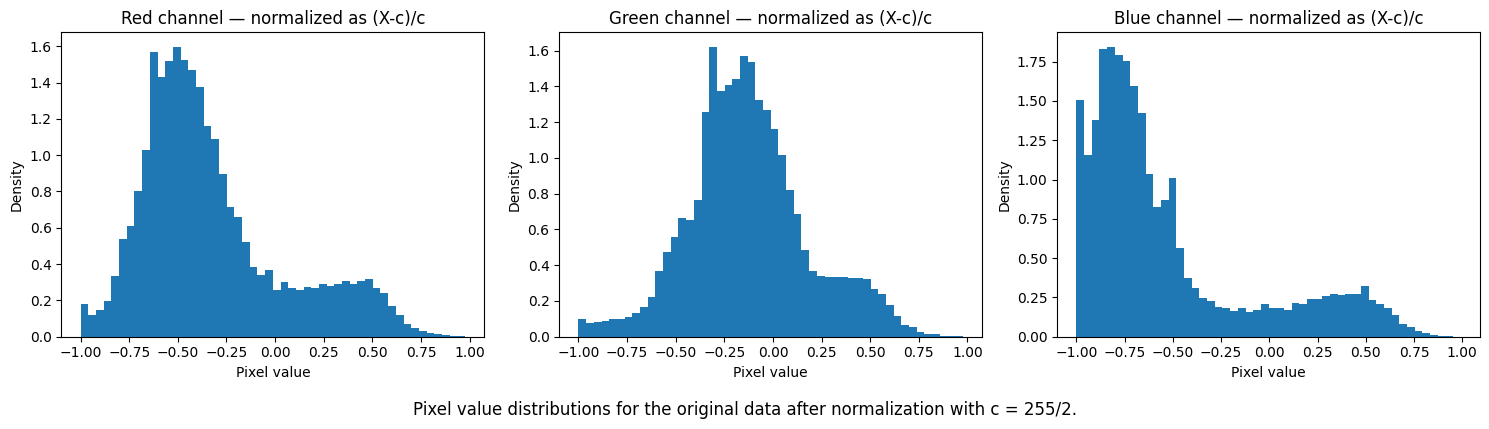

In [38]:
#============================================================================
# Normalizing  the original interval [0, 255] with the constant c = 255/2 
#============================================================================

c = 255/2 

# Apply the normalization by the constant c to the scaled data
image_cnorm = (image - c) / c

# Looking for the pixel distribution
channel_names = ["Red", "Green", "Blue"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].hist(image_cnorm[i].flatten(), bins=50, density=True)
    axes[i].set_title(f"{channel_names[i]} channel — normalized as (X-c)/c")
    axes[i].set_xlabel("Pixel value")
    axes[i].set_ylabel("Density")
    
caption_text = 'Pixel value distributions for the original data after normalization with c = 255/2.'
fig.text(0.5, -0.05, caption_text, ha='center', fontsize=12)

plt.tight_layout()
plt.show()

**Important Observation**

An alternative method for normalizing pixel data into the [−1, 1] interval follows a two-step approach commonly used in practice:

1. First, scale the pixels from [0, 255] to the interval $[0, 1]$.

2. Then, apply a normalization transformation with $c=0.5$ across each channel (why $c = 0.5$, because in this case $max(X_{scaled}) = 1$).

This two-step procedure is the standard approach in many deep learning frameworks. It is mathematically equivalent to applying a single transformation with $c = X_{\small{\mbox{max}⁡}}\,/\,2$ directly to the original raw pixel data. We can see this by comparing the following histograms with the previous ones. 


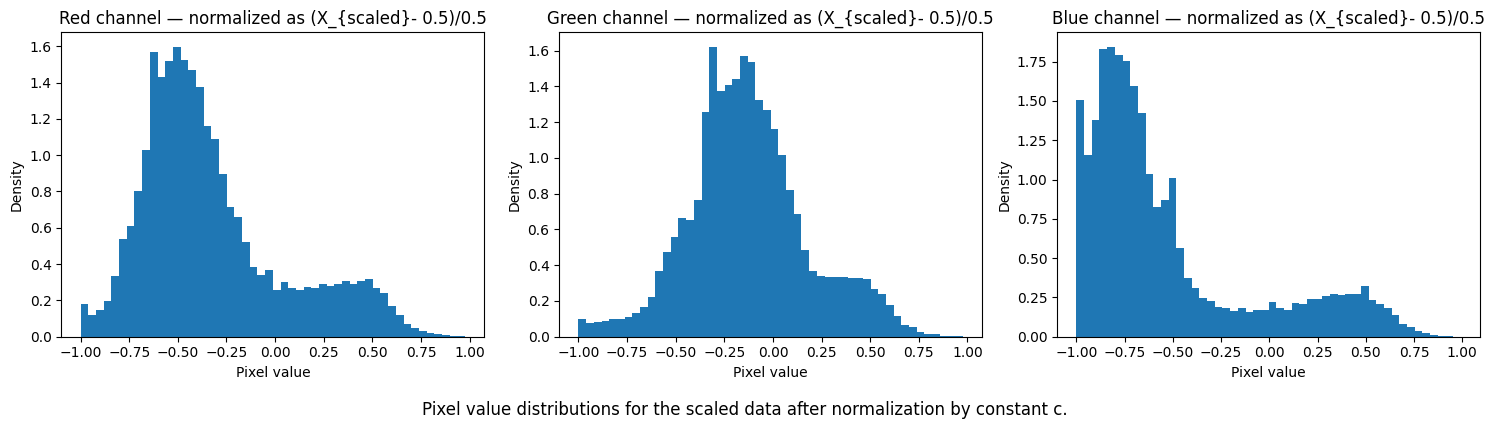

In [27]:
#=========================================================
# Normalizing (in the standard approach)  the scaled data  
#=========================================================
c = 0.5

# Apply the normalization by the constant c to the scaled data
image_cnorm = (image_scaled - c) / c

# Looking for the pixel distribution
channel_names = ["Red", "Green", "Blue"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].hist(image_cnorm[i].flatten(), bins=50, density=True)
    axes[i].set_title(f"{channel_names[i]} channel — normalized as (X_{{scaled}}- 0.5)/0.5")
    axes[i].set_xlabel("Pixel value")
    axes[i].set_ylabel("Density")
    
caption_text = 'Pixel value distributions for the scaled data after normalization by constant c.'
fig.text(0.5, -0.05, caption_text, ha='center', fontsize=12)

plt.tight_layout()
plt.show()


In [32]:
# computes mean/std per channel automatically
means_cnorm = image_cnorm.float().mean(dim=(1,2), keepdim=True)
stds_cnorm  = image_cnorm.float().std(dim=(1,2), keepdim=True)
print(means_cnorm)

tensor([[[-0.3239]],

        [[-0.1257]],

        [[-0.5236]]])


 We see that these two normalizations in this section are the same, and that : 
 
 * Skewness is preserved
 * They put the data into the $[−1, 1]$ range so that the model doesn't struggle with all-positive inputs.


# Using PyTorch for the preprocessing

Another way to perform these steps is through a PyTorch pipeline. As mentioned earlier, PyTorch first scales the pixel values and then applies normalization. 

In PyTorch, the callable transform *transforms.ToTensor()*  performs the following operations in one step: 
* The shape is given as (C, H W).
* The image is transformed into a tensor.
* The  pixel values are rescaled to $[0,1]$. The resulting tensor has type  torch.float32


In [28]:
# applying transforms.ToTensor to the original image
img_t = transforms.ToTensor()(image_spl) 
print(img_t.shape)
print("type:", type(img_t))
img_t

torch.Size([3, 240, 320])
type: <class 'torch.Tensor'>


tensor([[[0.3059, 0.3059, 0.3059,  ..., 0.2941, 0.2902, 0.2863],
         [0.3137, 0.3137, 0.3137,  ..., 0.2824, 0.2784, 0.2784],
         [0.3294, 0.3294, 0.3255,  ..., 0.2706, 0.2706, 0.2706],
         ...,
         [0.3059, 0.3137, 0.3216,  ..., 0.1137, 0.0824, 0.0627],
         [0.3137, 0.3255, 0.3333,  ..., 0.1216, 0.1020, 0.0902],
         [0.3216, 0.3333, 0.3412,  ..., 0.1373, 0.1412, 0.1255]],

        [[0.4235, 0.4235, 0.4235,  ..., 0.3765, 0.3725, 0.3686],
         [0.4314, 0.4314, 0.4314,  ..., 0.3647, 0.3608, 0.3608],
         [0.4471, 0.4471, 0.4431,  ..., 0.3529, 0.3529, 0.3529],
         ...,
         [0.4275, 0.4353, 0.4471,  ..., 0.2588, 0.2392, 0.2196],
         [0.4353, 0.4471, 0.4588,  ..., 0.2745, 0.2353, 0.1961],
         [0.4431, 0.4549, 0.4667,  ..., 0.2902, 0.2510, 0.1725]],

        [[0.1725, 0.1725, 0.1804,  ..., 0.2157, 0.2118, 0.2078],
         [0.1804, 0.1804, 0.1882,  ..., 0.2039, 0.2000, 0.2000],
         [0.1961, 0.2039, 0.2000,  ..., 0.1922, 0.1922, 0.

In [29]:
print(img_t.min(), img_t.max())


tensor(0.) tensor(1.)


## Selecting all images 

To work with all images, it is better to construct a pipeline that performs all the steps described above in a fast and efficient way. I will use all the images in the dandelion dataset.


In [30]:
# Define the transformations
my_transformations = transforms.Compose([
    transforms.Resize((240, 240)),  # fix values H and W to 240
    transforms.ToTensor(),          # Converts PIL Image to a tensor and scales values to [0, 1]
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])  # Normalize with the constant value 0.5 to get  [-1, 1]
                                        ])

# Define a custom class
class DandelionDataset(Dataset):    
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = os.listdir(root_dir)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        
        img_path = os.path.join(self.root_dir, self.image_paths[idx])
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image


dataset = DandelionDataset(
    root_dir=dandelion_dir,
    transform=my_transformations
)

loader = torch.utils.data.DataLoader(dataset)

## Observations: 

* I have created the custom dataset "DandelionDataset" because I am working with the directory "dandelion". This set contains just images. Originally, I wanted to use ImageFolder. But this option just work when the root directory contains subfolders, with each subfolder repressenting a class. Inside "dandelion" there are no subfolders, so ImageFolder cannot detect classes.
*  In the last line, inside DataLoader, the default value for the omitted batch size is 1. It means that in this case, the DataLoader will return one sample at a time. 

One of the most interesting takeaways from this exploration is that all the normalization methods discussed are actually special cases of the 1D Affine Transformation:
$$ X  \rightarrow b\, (X - a) $$

Whether I am scaling to [0,1], shifting to [−1,1], or performing Z-score standardization, the underlying operation remains a linear shift and a scale. 

## References:

* Eli Stevens, Luca Antiga, Thomas Viehman, "Deep Learning with PyTorch", 2020 by Manning Publications.
* [Understanding Bilinear Image Resizing](https://chao-ji.github.io/jekyll/update/2018/07/19/BilinearResize.html)